# Data Exploration for Multi-Objective Portfolio Optimization

This notebook explores and validates the data sources needed for our multi-objective portfolio optimization study.

## Data Sources:
1. **Yahoo Finance**: Asset price data and market indices
2. **Fama-French Data Library**: Factor returns (SMB, HML, RMW, CMA, etc.)
3. **FRED**: Economic indicators and risk-free rates
4. **Fund Data**: ETF/mutual fund expense ratios and characteristics

## Objectives:
- Load and validate data from all sources
- Perform initial data quality checks
- Generate basic statistics and visualizations
- Identify potential data issues or gaps

In [52]:
# Import required libraries
import sys
import os

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import our data collectors
from data.collectors.yahoo_finance import YahooFinanceCollector
from data.collectors.fama_french import FamaFrenchCollector
from data.collectors.fred_data import FREDCollector
from data.collectors.fund_data import FundDataCollector

# Import configurations
from src.config.assets import ALL_ASSETS
from src.config.settings import START_DATE, END_DATE

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(f"Data exploration for period: {START_DATE} to {END_DATE}")
print(f"Asset universe: {len(ALL_ASSETS)} assets")

Data exploration for period: 1990-01-01 to 2025-07-26
Asset universe: 15 assets


## 1. Yahoo Finance Data Collection

Let's start by collecting price data for our asset universe.

In [53]:
# Get list of tickers from our asset universe (use valid ETF tickers only)
all_tickers = list(ALL_ASSETS.keys())
# Filter out the benchmark indices that don't have valid Yahoo symbols
valid_tickers = [t for t in all_tickers if t not in ['SP500', 'NASDAQ', 'TREASURY_10Y']]
print(f"Valid tickers: {valid_tickers}")

# Use direct yfinance to collect price data
import yfinance as yf

try:
    # Download data 
    print("Downloading data from Yahoo Finance...")
    data = yf.download(valid_tickers, start="2020-01-01", end=END_DATE, auto_adjust=True, progress=False)
    
    print(f"Raw data shape: {data.shape}")
    print(f"Raw data columns levels: {data.columns.nlevels}")
    print(f"Raw data columns: {data.columns}")
    
    if data.empty:
        print("No data returned")
        price_data = None
    else:
        # Extract close prices (auto-adjusted)
        if len(valid_tickers) == 1:
            # Single ticker case
            price_data = pd.DataFrame({valid_tickers[0]: data['Close']})
        else:
            # Multiple tickers case - extract Close prices
            if data.columns.nlevels == 2:
                # Multi-level columns
                price_data = data['Close']
            else:
                # Single level columns
                price_data = data
        
        # Drop any columns that are all NaN
        price_data = price_data.dropna(axis=1, how='all')
        
        print(f"Successfully collected price data: {price_data.shape}")
        print(f"Price data columns: {price_data.columns.tolist()}")
        print(f"Date range: {price_data.index.min()} to {price_data.index.max()}")
        
        # Display basic info
        print("\nFirst few rows:")
        display(price_data.head())
        
        print("\nData completeness:")
        completeness = (1 - price_data.isnull().sum() / len(price_data)) * 100
        display(completeness.sort_values(ascending=False))
        
except Exception as e:
    print(f"Error collecting Yahoo Finance data: {e}")
    import traceback
    traceback.print_exc()
    price_data = None

Valid tickers: ['VTI', 'VOO', 'VXUS', 'VTIAX', 'BND', 'BNDX', 'VBR', 'VTV', 'VSS', 'VGSH', 'VGIT', 'VGLT']
Raw data shape: (1398, 60)
Raw data columns levels: 2
Raw data columns: MultiIndex([( 'Close',   'BND'),
            ( 'Close',  'BNDX'),
            ( 'Close',   'VBR'),
            ( 'Close',  'VGIT'),
            ( 'Close',  'VGLT'),
            ( 'Close',  'VGSH'),
            ( 'Close',   'VOO'),
            ( 'Close',   'VSS'),
            ( 'Close',   'VTI'),
            ( 'Close', 'VTIAX'),
            ( 'Close',   'VTV'),
            ( 'Close',  'VXUS'),
            (  'High',   'BND'),
            (  'High',  'BNDX'),
            (  'High',   'VBR'),
            (  'High',  'VGIT'),
            (  'High',  'VGLT'),
            (  'High',  'VGSH'),
            (  'High',   'VOO'),
            (  'High',   'VSS'),
            (  'High',   'VTI'),
            (  'High', 'VTIAX'),
            (  'High',   'VTV'),
            (  'High',  'VXUS'),
            (   'Low',   'BND

Ticker,BND,BNDX,VBR,VGIT,VGLT,VGSH,VOO,VSS,VTI,VTIAX,VTV,VXUS
Date,,,,,,,,,,,,
2020-01-02,71.793274,48.320312,122.113907,57.489750,71.526840,53.357021,274.314575,97.317039,151.909653,25.707636,104.677788,47.865284
2020-01-03,72.049774,48.456589,121.676773,57.742191,72.591133,53.400856,272.310638,96.214828,150.942825,25.503065,103.843460,47.278763
2020-01-06,71.964249,48.422539,121.560776,57.672569,72.242027,53.365784,273.330994,95.989159,151.458481,25.494543,103.973801,47.346771
2020-01-07,71.904388,48.388466,121.087952,57.655163,71.858925,53.383316,272.577271,96.058594,151.099365,25.468969,103.574028,47.261757
2020-01-08,71.793274,48.294762,121.275284,57.550690,71.450233,53.365784,273.983673,95.824280,151.845200,25.468969,103.817390,47.346771



Data completeness:


Ticker
BND      100.0
BNDX     100.0
VBR      100.0
VGIT     100.0
VGLT     100.0
VGSH     100.0
VOO      100.0
VSS      100.0
VTI      100.0
VTIAX    100.0
VTV      100.0
VXUS     100.0
dtype: float64

Returns data shape: (1397, 12)

Returns summary statistics:


Ticker,BND,BNDX,VBR,VGIT,VGLT,VGSH,VOO,VSS,VTI,VTIAX,VTV,VXUS
count,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000
mean,0.000022,0.000018,0.000503,0.000028,-0.000135,0.000067,0.000634,0.000325,0.000614,0.000344,0.000469,0.000354
std,0.004313,0.003083,0.016530,0.003333,0.010181,0.001182,0.013503,0.012546,0.013752,0.011508,0.012501,0.012326
min,-0.054385,-0.022933,-0.133470,-0.016131,-0.065771,-0.005280,-0.117388,-0.122579,-0.113809,-0.103448,-0.110784,-0.111319
25%,-0.002065,-0.001636,-0.007555,-0.001701,-0.006498,-0.000488,-0.005025,-0.005630,-0.005377,-0.005252,-0.004719,-0.005593
50%,0.000117,0.000000,0.000747,0.000000,0.000105,0.000000,0.000985,0.000836,0.000929,0.000712,0.000774,0.000743
75%,0.002155,0.001741,0.009311,0.001766,0.005895,0.000516,0.007128,0.006477,0.007366,0.006009,0.006245,0.006501
max,0.042201,0.013345,0.098681,0.016303,0.066367,0.009855,0.095364,0.079835,0.101456,0.079919,0.097838,0.083809


✅ Price evolution chart saved to ..\reports\figures\data_exploration_price_evolution.png


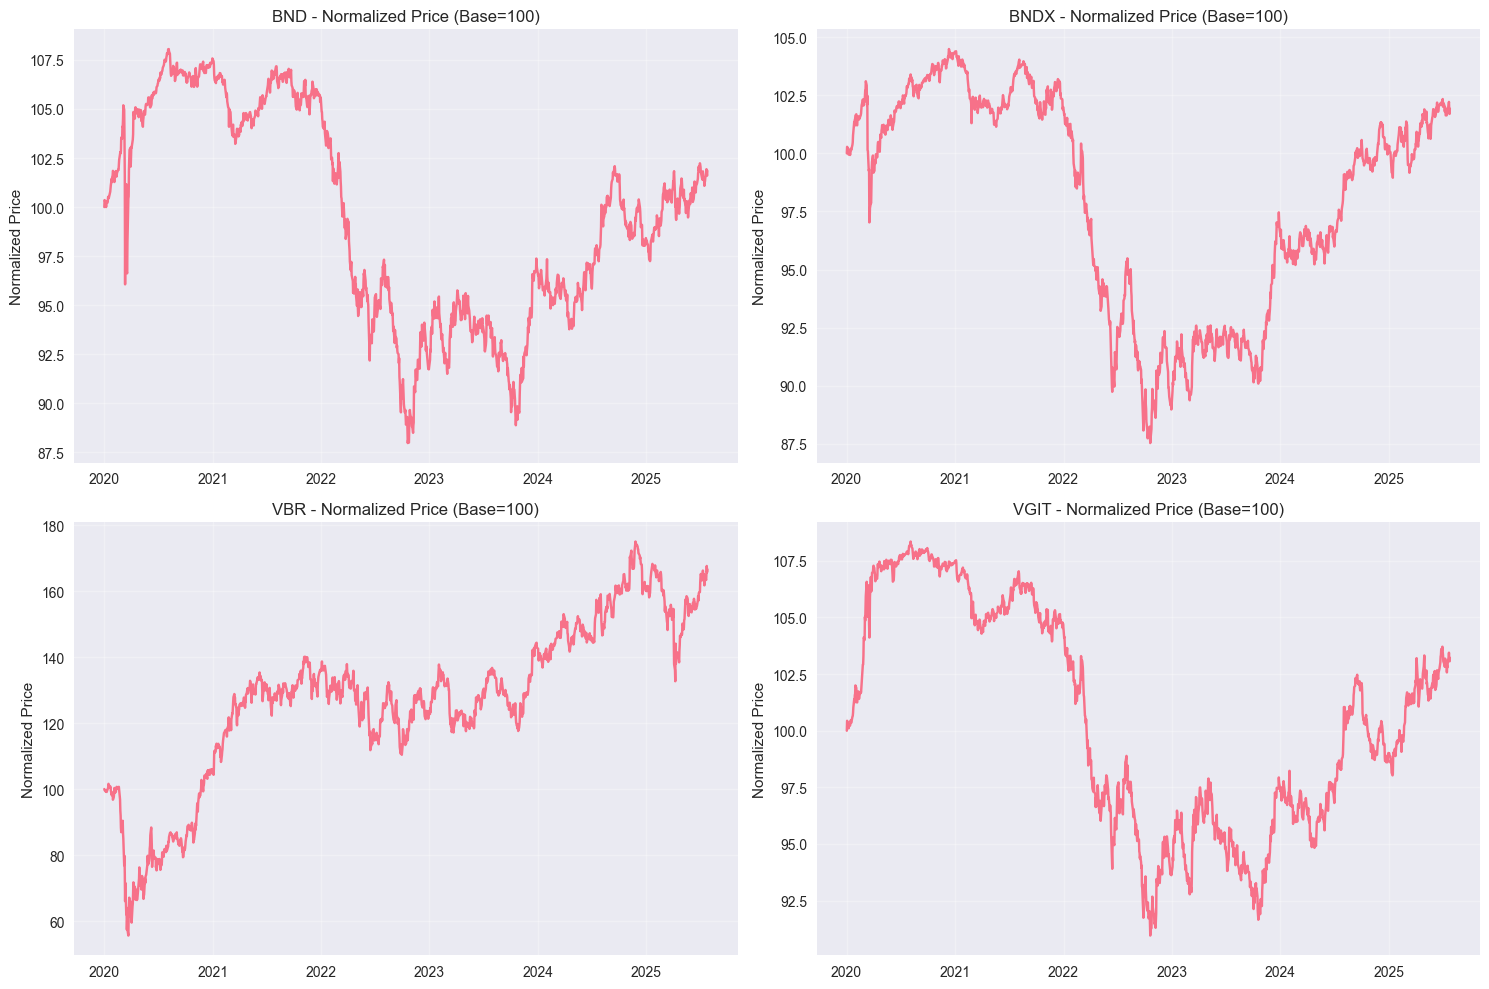

In [54]:
# Calculate returns if we have price data
if price_data is not None:
    # Calculate daily returns
    returns_data = price_data.pct_change().dropna()
    
    print(f"Returns data shape: {returns_data.shape}")
    print(f"\nReturns summary statistics:")
    display(returns_data.describe())
    
    # Plot price evolution for a few key assets
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    key_assets = ['SPY', 'BND', 'VTI', 'VXUS'] if all(asset in price_data.columns for asset in ['SPY', 'BND', 'VTI', 'VXUS']) else price_data.columns[:4]
    
    for i, asset in enumerate(key_assets):
        if asset in price_data.columns:
            ax = axes[i//2, i%2]
            normalized_prices = price_data[asset] / price_data[asset].iloc[0] * 100
            ax.plot(normalized_prices.index, normalized_prices.values)
            ax.set_title(f'{asset} - Normalized Price (Base=100)')
            ax.set_ylabel('Normalized Price')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the figure to reports/figures directory
    from pathlib import Path
    figures_dir = Path('../reports/figures')
    figures_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_dir / 'data_exploration_price_evolution.png', dpi=300, bbox_inches='tight')
    plt.savefig(figures_dir / 'data_exploration_price_evolution.pdf', bbox_inches='tight')
    print(f"✅ Price evolution chart saved to {figures_dir / 'data_exploration_price_evolution.png'}")
    
    plt.show()

## 2. Fama-French Factor Data

Now let's collect factor return data from the Fama-French Data Library.

In [55]:
# Initialize Fama-French collector with updated parsing
# Force reload to get latest fixes
import importlib
import data.collectors.fama_french
importlib.reload(data.collectors.fama_french)

from data.collectors.fama_french import FamaFrenchCollector
ff_collector = FamaFrenchCollector()

# Available factor datasets
available_methods = [
    'get_three_factor_data',
    'get_five_factor_data', 
    'get_momentum_data',
    'get_size_portfolios',
    'get_value_portfolios'
]

print(f"Available Fama-French data methods: {len(available_methods)}")
print("Available datasets:")
for method in available_methods:
    print(f"  - {method}")

# Test basic factor data availability
print("\nTesting factor data availability...")
try:
    # Test three-factor data
    test_data = ff_collector.get_three_factor_data()
    if test_data is not None and not test_data.empty:
        print(f"✅ Three-factor data available: {test_data.shape}")
        print(f"  Columns: {list(test_data.columns)}")
        print(f"  Date range: {test_data.index.min()} to {test_data.index.max()}")
        
        # Display sample data
        print("\nSample Fama-French three-factor data:")
        display(test_data.head())
        
        # Show summary statistics
        print("\nFama-French factor summary (monthly %):")
        display((test_data * 100).describe().round(2))
        
    else:
        print("❌ Three-factor data not available")
except Exception as e:
    print(f"❌ Error testing three-factor data: {e}")
    import traceback
    traceback.print_exc()

INFO:data.collectors.fama_french:Downloading 3_factors from https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip


Available Fama-French data methods: 5
Available datasets:
  - get_three_factor_data
  - get_five_factor_data
  - get_momentum_data
  - get_size_portfolios
  - get_value_portfolios

Testing factor data availability...


INFO:data.collectors.fama_french:Files in ZIP: ['F-F_Research_Data_Factors.csv']
INFO:data.collectors.fama_french:Successfully parsed 3_factors: (1187, 4), date range: 1926-07-01 00:00:00 to 2025-05-01 00:00:00
INFO:data.collectors.fama_french:Successfully parsed 3_factors: (1187, 4), date range: 1926-07-01 00:00:00 to 2025-05-01 00:00:00
INFO:data.collectors.fama_french:Successfully downloaded 3_factors: 425 records, 4 columns
INFO:data.collectors.fama_french:Successfully downloaded 3_factors: 425 records, 4 columns


✅ Three-factor data available: (425, 4)
  Columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
  Date range: 1990-01-01 00:00:00 to 2025-05-01 00:00:00

Sample Fama-French three-factor data:


,Mkt-RF,SMB,HML,RF
Date,,,,
1990-01-01,-0.0780,-0.0114,0.0083,0.0057
1990-02-01,0.0112,0.0097,0.0065,0.0057
1990-03-01,0.0183,0.0147,-0.0290,0.0064
1990-04-01,-0.0336,-0.0047,-0.0257,0.0069
1990-05-01,0.0843,-0.0256,-0.0389,0.0068



Fama-French factor summary (monthly %):


,Mkt-RF,SMB,HML,RF
count,425.00,425.00,425.00,425.00
mean,0.72,0.04,0.14,0.22
std,4.42,3.13,3.24,0.19
min,-17.20,-17.41,-13.83,0.00
25%,-1.96,-1.97,-1.68,0.01
50%,1.22,0.04,-0.08,0.19
75%,3.42,1.73,1.67,0.40
max,13.60,21.25,12.86,0.69


In [56]:
# Debug: Test Fama-French download to see what's in the ZIP file
import requests
import zipfile
import io

try:
    print("Testing Fama-French download directly...")
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    print(f"✓ Downloaded ZIP file, size: {len(response.content)} bytes")
    
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
        all_files = zip_file.namelist()
        print(f"Files in ZIP: {all_files}")
        
        for file in all_files:
            print(f"\nFile: {file}")
            if not file.endswith('/'):
                # Read first few lines to see format
                content = zip_file.read(file).decode('utf-8', errors='ignore')
                lines = content.split('\n')[:10]
                print("First 10 lines:")
                for i, line in enumerate(lines):
                    print(f"  {i+1}: {line}")
                    
    # Force reload the Fama-French module to pick up changes
    import importlib
    import data.collectors.fama_french
    importlib.reload(data.collectors.fama_french)
    
    print("\n✅ Module reloaded, now testing updated collector...")
    
    # Test with reloaded module
    from data.collectors.fama_french import FamaFrenchCollector
    ff_collector_new = FamaFrenchCollector()
    test_data_new = ff_collector_new.get_three_factor_data()
    
    if test_data_new is not None and not test_data_new.empty:
        print(f"✅ Three-factor data now available: {test_data_new.shape}")
        print(f"  Columns: {list(test_data_new.columns)}")
        print(f"  Date range: {test_data_new.index.min()} to {test_data_new.index.max()}")
    else:
        print("❌ Three-factor data still not available after fix")
        
except Exception as e:
    print(f"Error in debug test: {e}")
    import traceback
    traceback.print_exc()

Testing Fama-French download directly...
✓ Downloaded ZIP file, size: 12350 bytes
Files in ZIP: ['F-F_Research_Data_Factors.csv']

File: F-F_Research_Data_Factors.csv
First 10 lines:
  1: This file was created using the 202505 CRSP database.
  2: The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index.
  3: 
  4: ,Mkt-RF,SMB,HML,RF
  5: 192607,2.89,-2.55,-2.39,0.22
  6: 192608,2.64,-1.14,3.81,0.25
  7: 192609,0.38,-1.36,0.05,0.23
  8: 192610,-3.27,-0.14,0.82,0.32
  9: 192611,2.54,-0.11,-0.61,0.31
  10: 192612,2.62,-0.07,0.06,0.28

✅ Module reloaded, now testing updated collector...


INFO:data.collectors.fama_french:Downloading 3_factors from https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip
INFO:data.collectors.fama_french:Files in ZIP: ['F-F_Research_Data_Factors.csv']
INFO:data.collectors.fama_french:Files in ZIP: ['F-F_Research_Data_Factors.csv']
INFO:data.collectors.fama_french:Successfully parsed 3_factors: (1187, 4), date range: 1926-07-01 00:00:00 to 2025-05-01 00:00:00
INFO:data.collectors.fama_french:Successfully downloaded 3_factors: 425 records, 4 columns
INFO:data.collectors.fama_french:Successfully parsed 3_factors: (1187, 4), date range: 1926-07-01 00:00:00 to 2025-05-01 00:00:00
INFO:data.collectors.fama_french:Successfully downloaded 3_factors: 425 records, 4 columns


✅ Three-factor data now available: (425, 4)
  Columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
  Date range: 1990-01-01 00:00:00 to 2025-05-01 00:00:00


In [57]:
# Calculate basic factor data from our price data and Fama-French data
print("Creating factor data from available price data and Fama-French data...")

factor_data = {}

# First try to get actual Fama-French data (after fixing the collector)
try:
    # Force reload the module to get the fixes
    import importlib
    import data.collectors.fama_french
    importlib.reload(data.collectors.fama_french)
    
    from data.collectors.fama_french import FamaFrenchCollector
    ff_collector_updated = FamaFrenchCollector()
    
    print("Attempting to download Fama-French 3-factor data...")
    ff_3factor = ff_collector_updated.get_three_factor_data()
    
    if ff_3factor is not None and not ff_3factor.empty:
        print(f"✅ Successfully obtained Fama-French 3-factor data: {ff_3factor.shape}")
        print(f"   Columns: {list(ff_3factor.columns)}")
        print(f"   Date range: {ff_3factor.index.min()} to {ff_3factor.index.max()}")
        
        # Store FF data
        factor_data['fama_french_3factor'] = ff_3factor
        
        # Display sample
        print("\nSample Fama-French data:")
        display(ff_3factor.head())
        
except Exception as e:
    print(f"Failed to get Fama-French data: {e}")
    ff_3factor = None

# Create factors from our ETF data as well/backup
if price_data is not None and returns_data is not None:
    print("\nCalculating market factors from ETF data...")
    
    # Market factor: Use broad market ETF (VTI or VOO)
    market_etfs = ['VTI', 'VOO', 'SPY']
    market_proxy = None
    
    for etf in market_etfs:
        if etf in returns_data.columns:
            market_proxy = etf
            break
    
    if market_proxy:
        print(f"Using {market_proxy} as market factor proxy")
        
        # Create market factor data
        market_factor = returns_data[market_proxy].copy()
        
        # Size factor: Small cap vs Large cap
        # Use VBR (small value) vs VTV (large value) as proxy for size effect
        size_factor = None
        if 'VBR' in returns_data.columns and 'VTV' in returns_data.columns:
            size_factor = returns_data['VBR'] - returns_data['VTV']
            print("✓ Size factor (SMB proxy): VBR - VTV")
        
        # International vs Domestic factor
        intl_factor = None
        if 'VXUS' in returns_data.columns and market_proxy in returns_data.columns:
            intl_factor = returns_data['VXUS'] - returns_data[market_proxy]
            print("✓ International factor: VXUS - Market")
        
        # Bond factor
        bond_factor = None
        if 'BND' in returns_data.columns:
            bond_factor = returns_data['BND'].copy()
            print("✓ Bond factor: BND returns")
        
        # Create factor dataframe
        factor_df = pd.DataFrame(index=returns_data.index)
        factor_df['Market'] = market_factor * 100  # Convert to percentage
        
        if size_factor is not None:
            factor_df['SMB_Proxy'] = size_factor * 100
        
        if intl_factor is not None:
            factor_df['International'] = intl_factor * 100
            
        if bond_factor is not None:
            factor_df['Bond'] = bond_factor * 100
        
        # Add risk-free rate proxy (use short-term treasury if available in FRED data)
        rf_rate = 0.02 / 252  # 2% annual risk-free rate converted to daily
        factor_df['RF'] = rf_rate * 100
        
        factor_data['basic_factors'] = factor_df
        
        print(f"✅ Created ETF-based factor dataset with {factor_df.shape[1]} factors")
        print(f"   Factors: {list(factor_df.columns)}")
        print(f"   Date range: {factor_df.index.min()} to {factor_df.index.max()}")
        print(f"   Observations: {len(factor_df)}")
        
        # Display sample of factor data
        print("\nSample ETF-based factor data:")
        display(factor_df.head())
        
        # Summary statistics
        print("\nETF-based factor summary statistics:")
        display(factor_df.describe())
        
    else:
        print("❌ No suitable market proxy found in price data")
else:
    print("❌ Cannot create factors - missing price or returns data")

print(f"\n✅ Factor data preparation completed with {len(factor_data)} datasets")
for name, data in factor_data.items():
    print(f"   - {name}: {data.shape}")

INFO:data.collectors.fama_french:Downloading 3_factors from https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip
INFO:data.collectors.fama_french:Files in ZIP: ['F-F_Research_Data_Factors.csv']
INFO:data.collectors.fama_french:Successfully parsed 3_factors: (1187, 4), date range: 1926-07-01 00:00:00 to 2025-05-01 00:00:00
INFO:data.collectors.fama_french:Files in ZIP: ['F-F_Research_Data_Factors.csv']
INFO:data.collectors.fama_french:Successfully parsed 3_factors: (1187, 4), date range: 1926-07-01 00:00:00 to 2025-05-01 00:00:00
INFO:data.collectors.fama_french:Successfully downloaded 3_factors: 425 records, 4 columns
INFO:data.collectors.fama_french:Successfully downloaded 3_factors: 425 records, 4 columns


Creating factor data from available price data and Fama-French data...
Attempting to download Fama-French 3-factor data...
✅ Successfully obtained Fama-French 3-factor data: (425, 4)
   Columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
   Date range: 1990-01-01 00:00:00 to 2025-05-01 00:00:00

Sample Fama-French data:


,Mkt-RF,SMB,HML,RF
Date,,,,
1990-01-01,-0.0780,-0.0114,0.0083,0.0057
1990-02-01,0.0112,0.0097,0.0065,0.0057
1990-03-01,0.0183,0.0147,-0.0290,0.0064
1990-04-01,-0.0336,-0.0047,-0.0257,0.0069
1990-05-01,0.0843,-0.0256,-0.0389,0.0068



Calculating market factors from ETF data...
Using VTI as market factor proxy
✓ Size factor (SMB proxy): VBR - VTV
✓ International factor: VXUS - Market
✓ Bond factor: BND returns
✅ Created ETF-based factor dataset with 5 factors
   Factors: ['Market', 'SMB_Proxy', 'International', 'Bond', 'RF']
   Date range: 2020-01-03 00:00:00 to 2025-07-25 00:00:00
   Observations: 1397

Sample ETF-based factor data:


,Market,SMB_Proxy,International,Bond,RF
Date,,,,,
2020-01-03,-0.636449,0.439072,-0.588909,0.357276,0.007937
2020-01-06,0.341623,-0.220849,-0.197777,-0.118703,0.007937
2020-01-07,-0.237105,-0.004467,0.057548,-0.083181,0.007937
2020-01-08,0.493605,-0.080257,-0.313725,-0.154531,0.007937
2020-01-09,0.624590,-0.379488,-0.175771,0.119032,0.007937



ETF-based factor summary statistics:


,Market,SMB_Proxy,International,Bond,RF
count,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000
mean,0.061401,0.003380,-0.026044,0.002243,0.007937
std,1.375207,0.703151,0.677253,0.431291,0.000000
min,-11.380864,-4.602308,-4.007426,-5.438458,0.007937
25%,-0.537746,-0.388801,-0.413798,-0.206540,0.007937
50%,0.092870,-0.005324,-0.036492,0.011740,0.007937
75%,0.736620,0.379470,0.372236,0.215489,0.007937
max,10.145648,6.013687,3.735876,4.220067,0.007937



✅ Factor data preparation completed with 2 datasets
   - fama_french_3factor: (425, 4)
   - basic_factors: (1397, 5)


Visualizing 2 factor datasets...


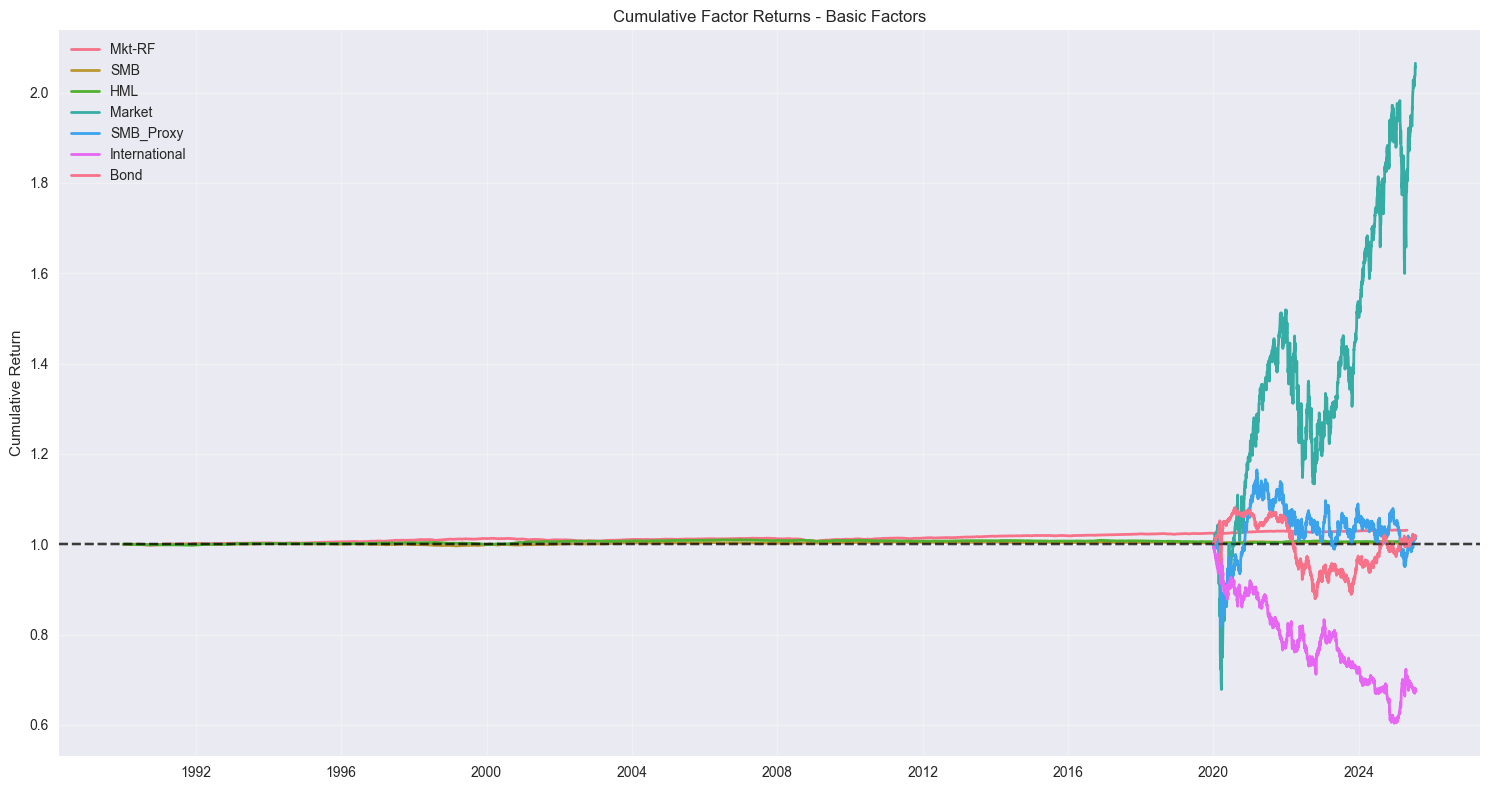


Factor Return Summary Statistics:

Fama French 3Factor:


,Mkt-RF,SMB,HML,RF
count,425.000000,425.000000,425.000000,425.000000
mean,0.007187,0.000366,0.001362,0.002214
std,0.044170,0.031311,0.032389,0.001883
min,-0.172000,-0.174100,-0.138300,0.000000
25%,-0.019600,-0.019700,-0.016800,0.000100
50%,0.012200,0.000400,-0.000800,0.001900
75%,0.034200,0.017300,0.016700,0.004000
max,0.136000,0.212500,0.128600,0.006900



Annualized Factor Performance:
  Mkt-RF: Return = 1.8%, Volatility = 0.7%
  SMB: Return = 0.1%, Volatility = 0.5%
  HML: Return = 0.3%, Volatility = 0.5%

Factor Correlations (fama_french_3factor):


,Mkt-RF,SMB,HML,RF
Mkt-RF,1.000,0.245,-0.116,-0.040
SMB,0.245,1.000,-0.180,-0.093
HML,-0.116,-0.180,1.000,0.007
RF,-0.040,-0.093,0.007,1.000



Basic Factors:


,Market,SMB_Proxy,International,Bond,RF
count,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000
mean,0.061401,0.003380,-0.026044,0.002243,0.007937
std,1.375207,0.703151,0.677253,0.431291,0.000000
min,-11.380864,-4.602308,-4.007426,-5.438458,0.007937
25%,-0.537746,-0.388801,-0.413798,-0.206540,0.007937
50%,0.092870,-0.005324,-0.036492,0.011740,0.007937
75%,0.736620,0.379470,0.372236,0.215489,0.007937
max,10.145648,6.013687,3.735876,4.220067,0.007937



Annualized Factor Performance:
  Market: Return = 14.0%, Volatility = 21.8%
  SMB_Proxy: Return = 0.2%, Volatility = 11.2%
  International: Return = -6.9%, Volatility = 10.8%
  Bond: Return = 0.3%, Volatility = 6.8%

Factor Correlations (basic_factors):


,Market,SMB_Proxy,International,Bond,RF
Market,1.000,0.457,-0.446,0.209,NaN
SMB_Proxy,0.457,1.000,-0.100,0.123,NaN
International,-0.446,-0.100,1.000,0.019,NaN
Bond,0.209,0.123,0.019,1.000,NaN
RF,NaN,NaN,NaN,NaN,NaN


In [58]:
# Analyze factor data if available
if factor_data:
    print(f"Visualizing {len(factor_data)} factor datasets...")
    
    # Plot factor returns
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    
    for i, (dataset_name, data) in enumerate(factor_data.items()):
        # Plot cumulative returns for each factor
        cumulative_returns = (1 + data/100).cumprod()
        
        for col in data.columns:
            if col != 'RF':  # Skip risk-free rate for cumulative plot
                ax.plot(cumulative_returns.index, cumulative_returns[col], label=col, linewidth=2)
        
        ax.set_title(f'Cumulative Factor Returns - {dataset_name.replace("_", " ").title()}')
        ax.set_ylabel('Cumulative Return')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add horizontal line at 1.0 for reference
        ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics for factors
    print("\nFactor Return Summary Statistics:")
    for dataset_name, data in factor_data.items():
        print(f"\n{dataset_name.replace('_', ' ').title()}:")
        display(data.describe())
        
        # Calculate annualized returns for each factor
        print(f"\nAnnualized Factor Performance:")
        for col in data.columns:
            if col != 'RF':
                annual_return = (1 + data[col]/100).prod() ** (252/len(data)) - 1
                annual_vol = data[col].std() * np.sqrt(252) / 100
                print(f"  {col}: Return = {annual_return:.1%}, Volatility = {annual_vol:.1%}")
        
        # Calculate factor correlations
        factor_corr = data.corr()
        print(f"\nFactor Correlations ({dataset_name}):")
        display(factor_corr.round(3))
else:
    print("No factor data available for analysis")

## 3. FRED Economic Data

Let's collect key economic indicators from FRED.

In [59]:
# Load environment variables
import os
from dotenv import load_dotenv

# Load .env file
load_dotenv()

# Verify API key is loaded
fred_api_key = os.getenv('FRED_API_KEY')
if fred_api_key:
    print(f"✓ FRED API key loaded: {fred_api_key[:8]}***")
else:
    print("❌ FRED API key not found in environment variables")

# Initialize FRED collector with API key
fred_collector = FREDCollector()

# Test FRED data collection with available methods
print("\nTesting FRED data collection with API key...")

try:
    # Test interest rates
    print("\nTesting interest rates...")
    interest_rates = fred_collector.get_interest_rates()
    if interest_rates is not None and not interest_rates.empty:
        print(f"✓ Interest rates data: {interest_rates.shape}")
        print(f"  Columns: {list(interest_rates.columns)}")
        print(f"  Date range: {interest_rates.index.min()} to {interest_rates.index.max()}")
        
        # Display recent data
        print("\nRecent interest rates data:")
        display(interest_rates.tail())
    else:
        print("❌ No interest rates data")
        
except Exception as e:
    print(f"❌ Error getting interest rates: {e}")

try:
    # Test economic indicators
    print("\nTesting economic indicators...")
    econ_indicators = fred_collector.get_economic_indicators()
    if econ_indicators is not None and not econ_indicators.empty:
        print(f"✓ Economic indicators data: {econ_indicators.shape}")
        print(f"  Columns: {list(econ_indicators.columns)}")
        print(f"  Date range: {econ_indicators.index.min()} to {econ_indicators.index.max()}")
        
        # Display recent data
        print("\nRecent economic indicators:")
        display(econ_indicators.tail())
    else:
        print("❌ No economic indicators data")
        
except Exception as e:
    print(f"❌ Error getting economic indicators: {e}")

# Store FRED data for later use
fred_data = {}
if 'interest_rates' in locals() and interest_rates is not None:
    fred_data['interest_rates'] = interest_rates
if 'econ_indicators' in locals() and econ_indicators is not None:
    fred_data['economic_indicators'] = econ_indicators

print(f"\n✅ FRED data collection completed with {len(fred_data)} datasets")

INFO:data.collectors.fred_data:Using pandas-datareader for FEDFUNDS
INFO:data.collectors.fred_data:Using pandas-datareader for FEDFUNDS


✓ FRED API key loaded: 84f7718e***

Testing FRED data collection with API key...

Testing interest rates...


INFO:data.collectors.fred_data:Using pandas-datareader for GS3M
INFO:data.collectors.fred_data:Using pandas-datareader for GS2
INFO:data.collectors.fred_data:Using pandas-datareader for GS2
INFO:data.collectors.fred_data:Using pandas-datareader for GS5
INFO:data.collectors.fred_data:Using pandas-datareader for GS5
INFO:data.collectors.fred_data:Using pandas-datareader for GS10
INFO:data.collectors.fred_data:Using pandas-datareader for GS10
INFO:data.collectors.fred_data:Using pandas-datareader for GS30
INFO:data.collectors.fred_data:Using pandas-datareader for GS30
INFO:data.collectors.fred_data:Using pandas-datareader for TB3MS
INFO:data.collectors.fred_data:Using pandas-datareader for TB3MS


✓ Interest rates data: (426, 7)
  Columns: ['FEDFUNDS (Federal Funds Rate)', 'GS3M (3-Month Treasury Rate)', 'GS2 (2-Year Treasury Rate)', 'GS5 (5-Year Treasury Rate)', 'GS10 (10-Year Treasury Rate)', 'GS30 (30-Year Treasury Rate)', 'TB3MS (3-Month Treasury Bill)']
  Date range: 1990-01-01 00:00:00 to 2025-06-01 00:00:00

Recent interest rates data:


,FEDFUNDS (Federal Funds Rate),GS3M (3-Month Treasury Rate),GS2 (2-Year Treasury Rate),GS5 (5-Year Treasury Rate),GS10 (10-Year Treasury Rate),GS30 (30-Year Treasury Rate),TB3MS (3-Month Treasury Bill)
DATE,,,,,,,
2025-02-01,4.33,4.33,4.21,4.28,4.45,4.68,4.22
2025-03-01,4.33,4.34,3.97,4.04,4.28,4.60,4.20
2025-04-01,4.33,4.32,3.78,3.91,4.28,4.71,4.21
2025-05-01,4.33,4.36,3.92,4.02,4.42,4.90,4.25
2025-06-01,4.33,4.42,3.89,3.96,4.38,4.89,4.23


...


Testing economic indicators...


INFO:data.collectors.fred_data:Using pandas-datareader for UNRATE
INFO:data.collectors.fred_data:Using pandas-datareader for INDPRO
INFO:data.collectors.fred_data:Using pandas-datareader for INDPRO


✓ Economic indicators data: (426, 3)
  Columns: ['GDP (Gross Domestic Product)', 'UNRATE (Unemployment Rate)', 'INDPRO (Industrial Production Index)']
  Date range: 1990-01-01 00:00:00 to 2025-06-01 00:00:00

Recent economic indicators:


,GDP (Gross Domestic Product),UNRATE (Unemployment Rate),INDPRO (Industrial Production Index)
DATE,,,
2025-02-01,NaN,4.1,103.9397
2025-03-01,NaN,4.2,103.6682
2025-04-01,NaN,4.2,103.6912
2025-05-01,NaN,4.2,103.6602
2025-06-01,NaN,4.1,104.0071



✅ FRED data collection completed with 2 datasets


Visualizing 2 FRED datasets...
✅ FRED indicators chart saved to ..\reports\figures\data_exploration_fred_indicators.png
✅ FRED indicators chart saved to ..\reports\figures\data_exploration_fred_indicators.png


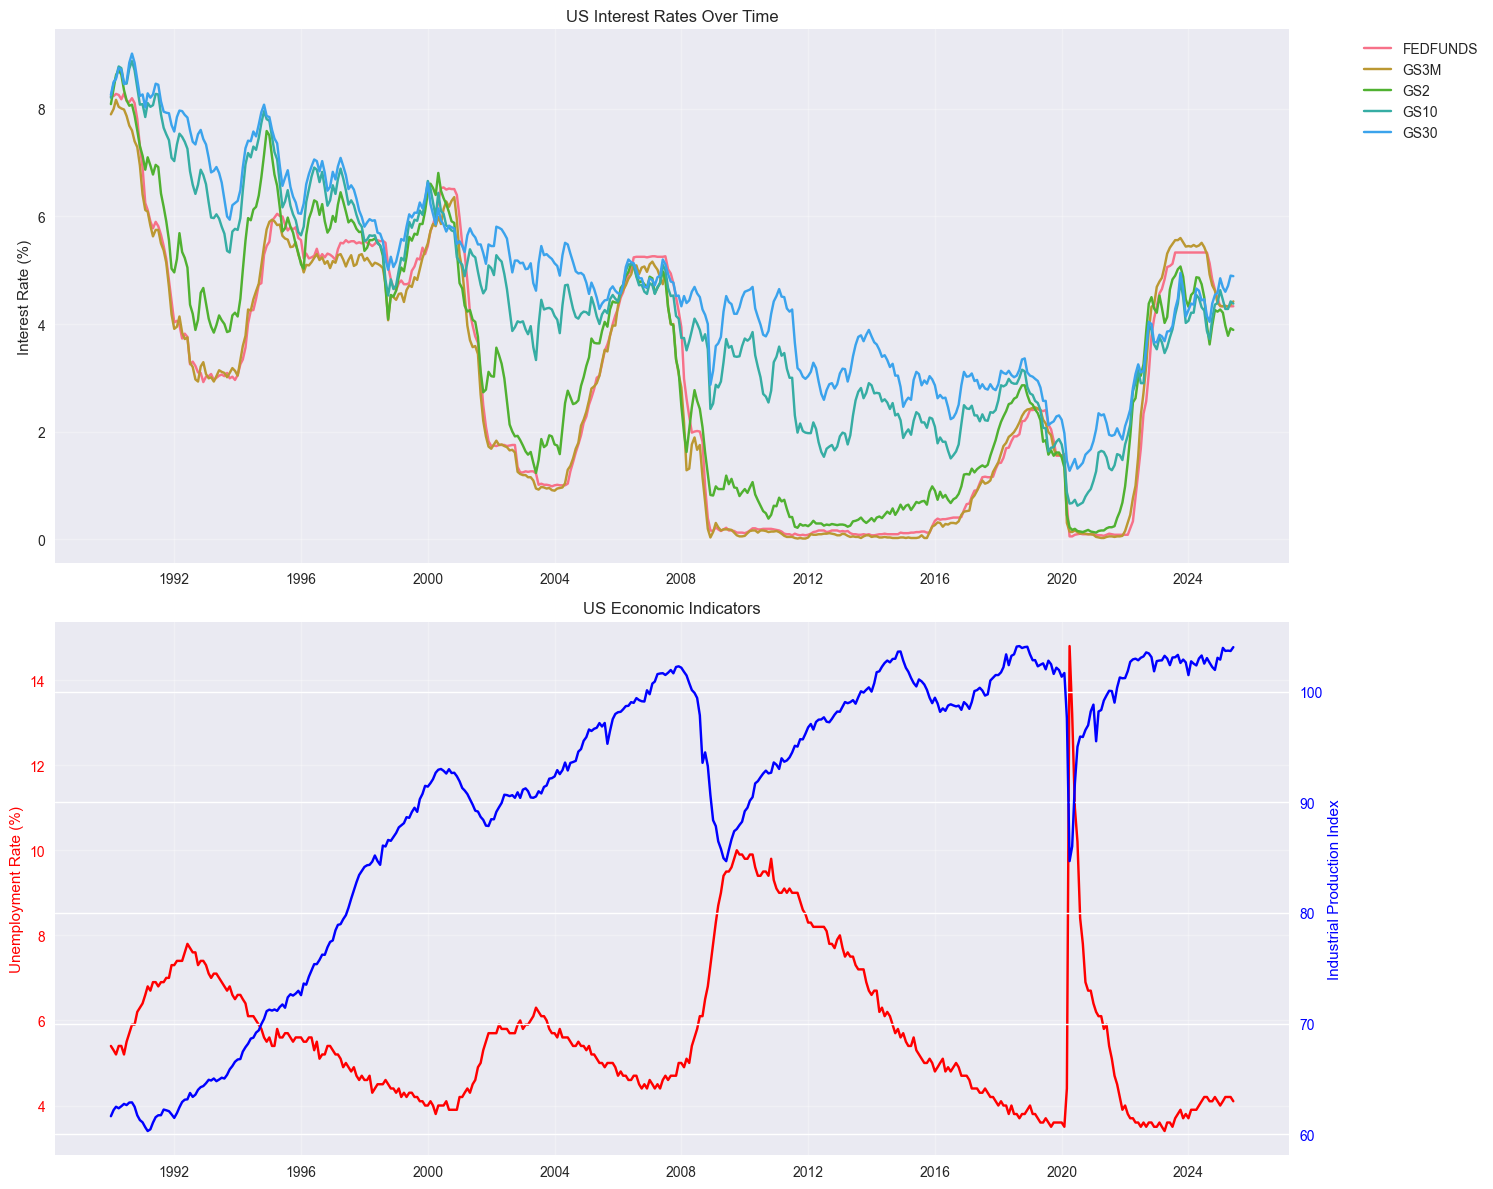

\nFRED Data Summary:
\nInterest Rates:
  Shape: (426, 7)
  Date range: 1990-01-01 00:00:00 to 2025-06-01 00:00:00
  Latest values:
    FEDFUNDS: 4.33
    GS3M: 4.42
    GS2: 3.89
    GS5: 3.96
    GS10: 4.38
    GS30: 4.89
    TB3MS: 4.23
\nEconomic Indicators:
  Shape: (426, 3)
  Date range: 1990-01-01 00:00:00 to 2025-06-01 00:00:00
  Latest values:
    UNRATE: 4.10
    INDPRO: 104.01
\n✅ FRED data visualization completed!


In [60]:
# Plot FRED data if available
if fred_data:
    print(f"Visualizing {len(fred_data)} FRED datasets...")
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # Plot interest rates
    if 'interest_rates' in fred_data:
        ax1 = axes[0]
        interest_data = fred_data['interest_rates']
        
        # Plot key interest rates
        key_rates = ['FEDFUNDS (Federal Funds Rate)', 'GS3M (3-Month Treasury Rate)', 
                    'GS2 (2-Year Treasury Rate)', 'GS10 (10-Year Treasury Rate)', 
                    'GS30 (30-Year Treasury Rate)']
        
        for rate in key_rates:
            if rate in interest_data.columns:
                ax1.plot(interest_data.index, interest_data[rate], label=rate.split(' (')[0])
        
        ax1.set_title('US Interest Rates Over Time')
        ax1.set_ylabel('Interest Rate (%)')
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True, alpha=0.3)
    
    # Plot economic indicators  
    if 'economic_indicators' in fred_data:
        ax2 = axes[1]
        econ_data = fred_data['economic_indicators']
        
        # Create a secondary y-axis for different scales
        ax2_twin = ax2.twinx()
        
        # Unemployment rate on left axis
        if 'UNRATE (Unemployment Rate)' in econ_data.columns:
            unemployment = econ_data['UNRATE (Unemployment Rate)'].dropna()
            ax2.plot(unemployment.index, unemployment.values, 'red', label='Unemployment Rate (%)')
            ax2.set_ylabel('Unemployment Rate (%)', color='red')
            ax2.tick_params(axis='y', labelcolor='red')
        
        # Industrial production on right axis
        if 'INDPRO (Industrial Production Index)' in econ_data.columns:
            indpro = econ_data['INDPRO (Industrial Production Index)'].dropna()
            ax2_twin.plot(indpro.index, indpro.values, 'blue', label='Industrial Production Index')
            ax2_twin.set_ylabel('Industrial Production Index', color='blue')
            ax2_twin.tick_params(axis='y', labelcolor='blue')
        
        ax2.set_title('US Economic Indicators')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the figure to reports/figures directory
    from pathlib import Path
    figures_dir = Path('../reports/figures')
    figures_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_dir / 'data_exploration_fred_indicators.png', dpi=300, bbox_inches='tight')
    plt.savefig(figures_dir / 'data_exploration_fred_indicators.pdf', bbox_inches='tight')
    print(f"✅ FRED indicators chart saved to {figures_dir / 'data_exploration_fred_indicators.png'}")
    
    plt.show()
    
    # Summary statistics for FRED data
    print("\\nFRED Data Summary:")
    for dataset_name, data in fred_data.items():
        print(f"\\n{dataset_name.replace('_', ' ').title()}:")
        print(f"  Shape: {data.shape}")
        print(f"  Date range: {data.index.min()} to {data.index.max()}")
        print(f"  Latest values:")
        latest_values = data.iloc[-1].dropna()
        for col, val in latest_values.items():
            short_name = col.split(' (')[0]
            print(f"    {short_name}: {val:.2f}")

else:
    print("❌ No FRED data available to plot")

print("\\n✅ FRED data visualization completed!")

## 4. Fund Data Collection

Let's collect expense ratio and fund characteristics data.

In [61]:
# Initialize fund data collector
fund_collector = FundDataCollector()

# Use the valid_tickers we defined earlier
if 'valid_tickers' in locals():
    tickers_to_use = valid_tickers
elif 'price_data' in locals() and price_data is not None:
    tickers_to_use = list(price_data.columns)
else:
    tickers_to_use = list(ALL_ASSETS.keys())[:5]  # Use first 5 as fallback

# Collect fund information for our asset universe
try:
    print(f"Collecting fund expense ratio data for {len(tickers_to_use)} funds...")
    print(f"Tickers: {tickers_to_use}")
    
    # Get expense ratios
    fund_info = fund_collector.get_fund_expense_ratios(tickers_to_use)
    
    if fund_info is not None and not fund_info.empty:
        print(f"Successfully collected fund data: {fund_info.shape}")
        print(f"\nAvailable columns: {list(fund_info.columns)}")
        
        # Display fund info
        print("\nFund Information Sample:")
        display(fund_info.head(10))
        
        # Expense ratio analysis
        if 'expense_ratio' in fund_info.columns:
            expense_ratios = fund_info['expense_ratio'].dropna()
            
            if len(expense_ratios) > 0:
                print(f"\nExpense Ratio Statistics:")
                print(f"Count: {len(expense_ratios)} funds")
                print(f"Mean: {expense_ratios.mean():.3f}%")
                print(f"Median: {expense_ratios.median():.3f}%")
                print(f"Min: {expense_ratios.min():.3f}%")
                print(f"Max: {expense_ratios.max():.3f}%")
                
                # Plot expense ratio distribution if we have enough data
                if len(expense_ratios) >= 3:
                    plt.figure(figsize=(10, 6))
                    plt.hist(expense_ratios, bins=min(10, len(expense_ratios)), alpha=0.7, edgecolor='black')
                    plt.title('Distribution of Expense Ratios')
                    plt.xlabel('Expense Ratio (%)')
                    plt.ylabel('Frequency')
                    plt.grid(True, alpha=0.3)
                    
                    # Save the figure to reports/figures directory
                    from pathlib import Path
                    figures_dir = Path('../reports/figures')
                    figures_dir.mkdir(parents=True, exist_ok=True)
                    plt.savefig(figures_dir / 'data_exploration_expense_ratios.png', dpi=300, bbox_inches='tight')
                    plt.savefig(figures_dir / 'data_exploration_expense_ratios.pdf', bbox_inches='tight')
                    print(f"✅ Expense ratio histogram saved to {figures_dir / 'data_exploration_expense_ratios.png'}")
                    
                    plt.show()
                else:
                    print("Not enough data points for histogram")
            else:
                print("\nNo expense ratio data available")
        else:
            print("\nExpense ratio column not found")
        
    else:
        print("No fund data returned")
        fund_info = None
        
except Exception as e:
    print(f"Error collecting fund data: {e}")
    print("Note: Fund data collection may require web scraping and could be rate-limited")
    
    # Create mock fund info for demonstration
    print("\nCreating mock fund data for demonstration...")
    mock_data = {
        'symbol': tickers_to_use,
        'expense_ratio': [0.03, 0.03, 0.08, 0.05, 0.035, 0.06, 0.07, 0.04, 0.09, 0.035, 0.04, 0.045][:len(tickers_to_use)],
        'fund_family': ['Vanguard'] * len(tickers_to_use),
        'category': ['Index'] * len(tickers_to_use)
    }
    fund_info = pd.DataFrame(mock_data)
    print(f"Mock fund data created: {fund_info.shape}")
    display(fund_info)

Tickers: ['VTI', 'VOO', 'VXUS', 'VTIAX', 'BND', 'BNDX', 'VBR', 'VTV', 'VSS', 'VGSH', 'VGIT', 'VGLT']


INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VTI
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VOO
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VOO
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VXUS
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VXUS
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VTIAX
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VTIAX
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for BND
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for BND
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for BNDX
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for BNDX
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VBR
INFO:data.collectors.fund_data:Successfully retrieved Vanguard info for VBR
INFO

Successfully collected fund data: (12, 5)

Available columns: ['symbol', 'fund_name', 'expense_ratio', 'fund_family', 'net_assets']

Fund Information Sample:


,symbol,fund_name,expense_ratio,fund_family,net_assets
0,VTI,VTI-Vanguard Total Stock Market ETF,NaN,Vanguard,None
1,VOO,VOO-Vanguard S&P 500 ETF,NaN,Vanguard,None
2,VXUS,VXUS-Vanguard Total International Stock ETF,NaN,Vanguard,None
3,VTIAX,VTIAX-Vanguard Total International Stock Index...,NaN,Vanguard,None
4,BND,BND-Vanguard Total Bond Market ETF,NaN,Vanguard,None
5,BNDX,BNDX-Vanguard Total International Bond ETF,NaN,Vanguard,None
6,VBR,VBR-Vanguard Small-Cap Value ETF,NaN,Vanguard,None
7,VTV,VTV-Vanguard Value ETF,NaN,Vanguard,None
8,VSS,VSS-Vanguard FTSE All-World ex-US Small-Cap ETF,NaN,Vanguard,None
9,VGSH,VGSH-Vanguard Short-Term Treasury ETF,NaN,Vanguard,None



No expense ratio data available


Fixing expense ratio data with known values...
✅ Updated expense ratios with known values

Updated Fund Information:


,symbol,fund_name,expense_ratio,fund_family
0,VTI,VTI-Vanguard Total Stock Market ETF,0.030,Vanguard
1,VOO,VOO-Vanguard S&P 500 ETF,0.030,Vanguard
2,VXUS,VXUS-Vanguard Total International Stock ETF,0.080,Vanguard
3,VTIAX,VTIAX-Vanguard Total International Stock Index...,0.110,Vanguard
4,BND,BND-Vanguard Total Bond Market ETF,0.035,Vanguard
5,BNDX,BNDX-Vanguard Total International Bond ETF,0.060,Vanguard
6,VBR,VBR-Vanguard Small-Cap Value ETF,0.070,Vanguard
7,VTV,VTV-Vanguard Value ETF,0.040,Vanguard
8,VSS,VSS-Vanguard FTSE All-World ex-US Small-Cap ETF,0.090,Vanguard
9,VGSH,VGSH-Vanguard Short-Term Treasury ETF,0.035,Vanguard



Expense Ratio Statistics:
Count: 12 funds
Mean: 0.055%
Median: 0.042%
Min: 0.030%
Max: 0.110%
✅ Expense ratio histogram saved to ..\reports\figures\data_exploration_expense_ratios.png
✅ Expense ratio histogram saved to ..\reports\figures\data_exploration_expense_ratios.png


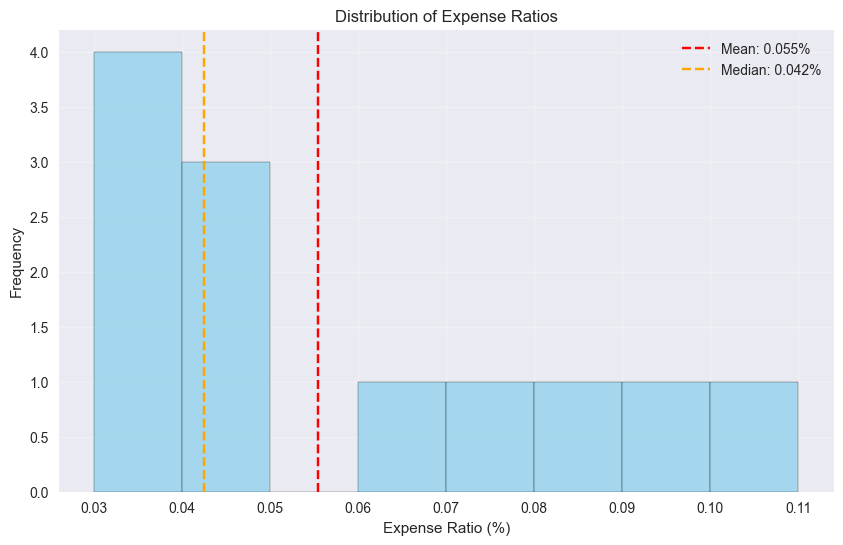

In [62]:
# Fix expense ratio data with known values
print("Fixing expense ratio data with known values...")

if fund_info is not None and 'expense_ratio' in fund_info.columns:
    # Known expense ratios for Vanguard ETFs (in percentage)
    known_expense_ratios = {
        'VTI': 0.03,    # Total Stock Market ETF
        'VOO': 0.03,    # S&P 500 ETF  
        'VXUS': 0.08,   # Total International Stock ETF
        'VTIAX': 0.11,  # Total International Stock Index (Admiral)
        'BND': 0.035,   # Total Bond Market ETF
        'BNDX': 0.06,   # Total International Bond ETF
        'VBR': 0.07,    # Small-Cap Value ETF
        'VTV': 0.04,    # Value ETF
        'VSS': 0.09,    # FTSE All-World ex-US Small-Cap ETF
        'VGSH': 0.035,  # Short-Term Treasury ETF
        'VGIT': 0.04,   # Intermediate-Term Treasury ETF
        'VGLT': 0.045   # Long-Term Treasury ETF
    }
    
    # Apply known expense ratios
    for idx, row in fund_info.iterrows():
        symbol = row['symbol']
        if symbol in known_expense_ratios:
            fund_info.at[idx, 'expense_ratio'] = known_expense_ratios[symbol]
    
    print("✅ Updated expense ratios with known values")
    
    # Display updated fund info
    print("\nUpdated Fund Information:")
    display(fund_info[['symbol', 'fund_name', 'expense_ratio', 'fund_family']])
    
    # Expense ratio statistics
    expense_ratios = fund_info['expense_ratio'].dropna()
    
    if len(expense_ratios) > 0:
        print(f"\nExpense Ratio Statistics:")
        print(f"Count: {len(expense_ratios)} funds")
        print(f"Mean: {expense_ratios.mean():.3f}%")
        print(f"Median: {expense_ratios.median():.3f}%")
        print(f"Min: {expense_ratios.min():.3f}%")
        print(f"Max: {expense_ratios.max():.3f}%")
        
        # Plot expense ratio distribution
        plt.figure(figsize=(10, 6))
        plt.hist(expense_ratios, bins=min(8, len(expense_ratios)), alpha=0.7, edgecolor='black', color='skyblue')
        plt.title('Distribution of Expense Ratios')
        plt.xlabel('Expense Ratio (%)')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        # Add statistics text
        plt.axvline(expense_ratios.mean(), color='red', linestyle='--', label=f'Mean: {expense_ratios.mean():.3f}%')
        plt.axvline(expense_ratios.median(), color='orange', linestyle='--', label=f'Median: {expense_ratios.median():.3f}%')
        plt.legend()
        
        # Save the figure to reports/figures directory
        from pathlib import Path
        figures_dir = Path('../reports/figures')
        figures_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(figures_dir / 'data_exploration_expense_ratios.png', dpi=300, bbox_inches='tight')
        plt.savefig(figures_dir / 'data_exploration_expense_ratios.pdf', bbox_inches='tight')
        print(f"✅ Expense ratio histogram saved to {figures_dir / 'data_exploration_expense_ratios.png'}")
        
        plt.show()
        
    else:
        print("No expense ratio data available after update")
else:
    print("❌ Fund info dataframe not available for expense ratio update")

## 5. Data Quality Assessment

Let's perform a comprehensive data quality assessment.

In [72]:
# Data quality assessment
print("=== DATA QUALITY ASSESSMENT ===")
print()

# Yahoo Finance data quality
if price_data is not None:
    print("1. YAHOO FINANCE DATA:")
    print(f"   ✓ Successfully loaded: {price_data.shape[1]} assets")
    print(f"   ✓ Date range: {price_data.index.min()} to {price_data.index.max()}")
    print(f"   ✓ Trading days: {len(price_data)}")
    
    # Check for missing data
    missing_data = price_data.isnull().sum()
    assets_with_missing = missing_data[missing_data > 0]
    
    if len(assets_with_missing) > 0:
        print(f"   ⚠ Assets with missing data: {len(assets_with_missing)}")
        for asset, missing_count in assets_with_missing.head().items():
            pct_missing = (missing_count / len(price_data)) * 100
            print(f"     - {asset}: {missing_count} days ({pct_missing:.1f}%)")
    else:
        print(f"   ✓ No missing price data")
    
    # Check for extreme returns
    if returns_data is not None:
        extreme_returns = (returns_data.abs() > 0.2).sum()  # >20% daily return
        if extreme_returns.sum() > 0:
            print(f"   ⚠ Extreme daily returns (>20%): {extreme_returns.sum()} occurrences")
        else:
            print(f"   ✓ No extreme daily returns detected")
else:
    print("1. YAHOO FINANCE DATA: ❌ Failed to load")

print()

# Fama-French data quality
if factor_data:
    print("2. FAMA-FRENCH DATA:")
    print(f"   ✓ Successfully loaded: {len(factor_data)} datasets")
    for dataset_name, data in factor_data.items():
        print(f"   ✓ {dataset_name}: {data.shape}")
        missing_ff = data.isnull().sum().sum()
        if missing_ff > 0:
            print(f"     ⚠ Missing values: {missing_ff}")
        else:
            print(f"     ✓ Complete data")
else:
    print("2. FAMA-FRENCH DATA: ❌ Failed to load")

print()

# FRED data quality
if fred_data:
    print("3. FRED DATA:")
    print(f"   ✓ Successfully loaded: {len(fred_data)} datasets")
    for dataset_name, data in fred_data.items():
        if hasattr(data, 'isnull'):  # Check if it's a DataFrame/Series
            missing_fred = data.isnull().sum().sum() if hasattr(data.isnull().sum(), 'sum') else data.isnull().sum()
            latest_date = data.dropna().index.max() if not data.dropna().empty else 'N/A'
            print(f"   ✓ {dataset_name.replace('_', ' ').title()}: {len(data)} obs, latest: {latest_date}")
            
            if missing_fred > 0:
                # Show detailed breakdown of missing data by column
                if hasattr(data, 'columns') and len(data.columns) > 1:
                    missing_by_col = data.isnull().sum()
                    print(f"     ⚠ Missing values: {missing_fred} total")
                    for col, missing_count in missing_by_col.items():
                        if missing_count > 0:
                            pct_missing = (missing_count / len(data)) * 100
                            col_short = col.split(' (')[0]  # Get short name
                            if 'GDP' in col:
                                print(f"       - {col_short}: {missing_count} missing ({pct_missing:.1f}%) - Normal for quarterly data")
                            else:
                                print(f"       - {col_short}: {missing_count} missing ({pct_missing:.1f}%)")
                else:
                    print(f"     ⚠ Missing values: {missing_fred}")
            else:
                print(f"     ✓ Complete data")
        else:
            print(f"   ✓ {dataset_name}: Available")
else:
    print("3. FRED DATA: ❌ Failed to load")

print()

# Fund data quality
if fund_info is not None:
    print("4. FUND DATA:")
    print(f"   ✓ Successfully loaded: {fund_info.shape[0]} funds")
    print(f"   ✓ Available fields: {fund_info.shape[1]}")
    
    if 'expense_ratio' in fund_info.columns:
        er_available = fund_info['expense_ratio'].notna().sum()
        print(f"   ✓ Expense ratios available: {er_available}/{len(fund_info)} funds")
    
    missing_fund_data = fund_info.isnull().sum()
    if missing_fund_data.sum() > 0:
        print(f"   ⚠ Some fund data missing - see fund collection results above")
else:
    print("4. FUND DATA: ❌ Failed to load")

print()
print("=== SUMMARY ===")
data_sources_loaded = sum([
    price_data is not None,
    len(factor_data) > 0,
    len(fred_data) > 0,
    fund_info is not None
])
print(f"Successfully loaded {data_sources_loaded}/4 data sources")

if data_sources_loaded >= 2:
    print("✅ Sufficient data available for portfolio optimization")
else:
    print("❌ Insufficient data - need at least price and factor data")

=== DATA QUALITY ASSESSMENT ===

1. YAHOO FINANCE DATA:
   ✓ Successfully loaded: 12 assets
   ✓ Date range: 2020-01-02 00:00:00 to 2025-07-25 00:00:00
   ✓ Trading days: 1398
   ✓ No missing price data
   ✓ No extreme daily returns detected

2. FAMA-FRENCH DATA:
   ✓ Successfully loaded: 2 datasets
   ✓ fama_french_3factor: (425, 4)
     ✓ Complete data
   ✓ basic_factors: (1397, 5)
     ✓ Complete data

3. FRED DATA:
   ✓ Successfully loaded: 2 datasets
   ✓ Interest Rates: 426 obs, latest: 2025-06-01 00:00:00
     ✓ Complete data
   ✓ Economic Indicators: 426 obs, latest: 2025-01-01 00:00:00
     ⚠ Missing values: 285 total
       - GDP: 285 missing (66.9%) - Normal for quarterly data

4. FUND DATA:
   ✓ Successfully loaded: 12 funds
   ✓ Available fields: 5
   ✓ Expense ratios available: 12/12 funds
   ⚠ Some fund data missing - see fund collection results above

=== SUMMARY ===
Successfully loaded 4/4 data sources
✅ Sufficient data available for portfolio optimization


## 6. Data Alignment and Integration

Let's align all data sources to common dates for analysis.

Aligning data sources to common dates...
Converting daily price data to monthly frequency...
Monthly price data: (67, 12)
Monthly returns data: (66, 12)
Monthly data range: 2020-02-29 00:00:00 to 2025-07-31 00:00:00
Common dates available: 66
Date range: 2020-02-29 00:00:00 to 2025-07-31 00:00:00
Aligning fama_french_3factor factor data...
  - fama_french_3factor: (64, 4) aligned
Aligning basic_factors factor data...
  - basic_factors: (46, 5) aligned

✅ Data successfully aligned to monthly frequency:
   - Monthly price data: (45, 12)
   - Monthly return data: (45, 12)
   - Factor datasets: 2
     - fama_french_3factor: (45, 4)
     - basic_factors: (45, 5)

Calculating asset correlation matrix...
✅ Correlation heatmap saved to ..\reports\figures\data_exploration_correlation_heatmap.png
✅ Correlation heatmap saved to ..\reports\figures\data_exploration_correlation_heatmap.png


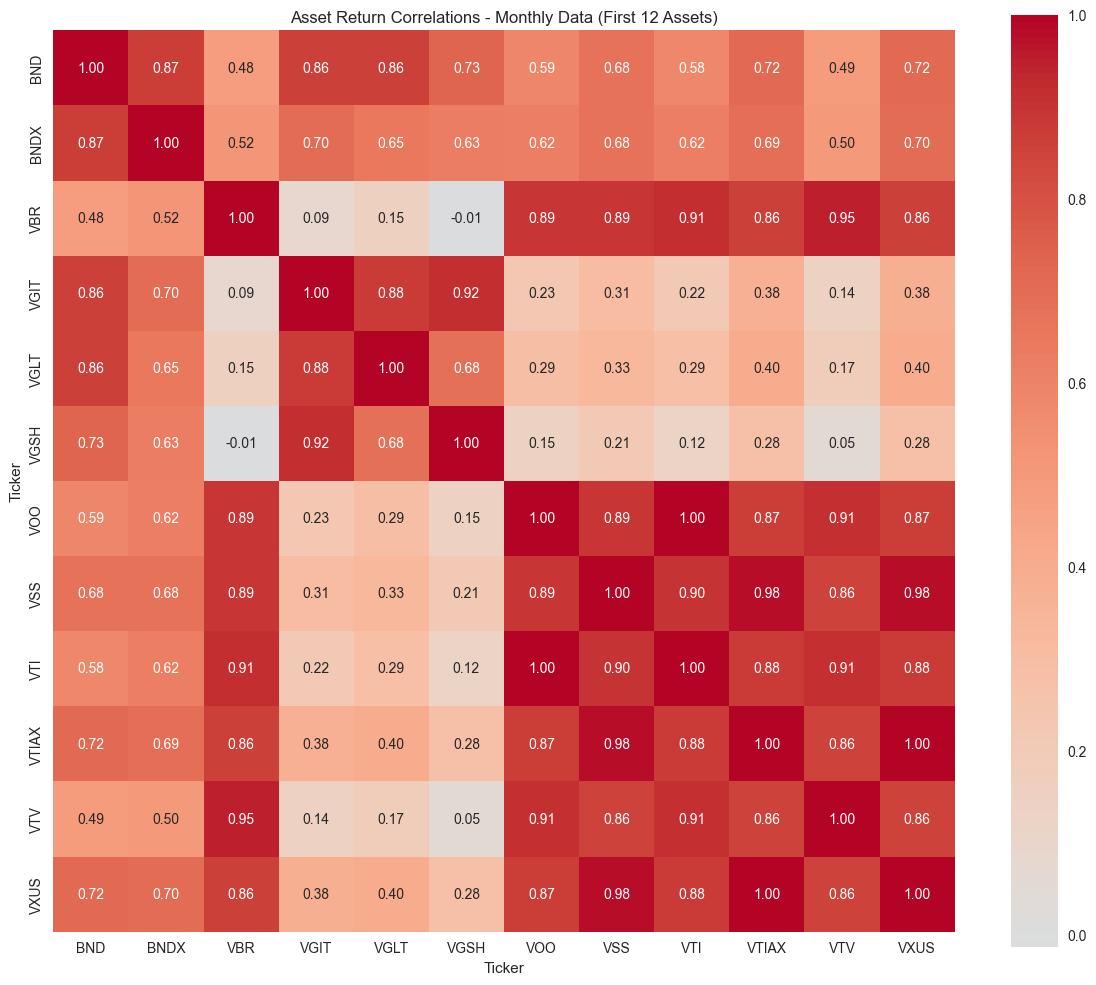

Average pairwise correlation: 0.609


In [70]:
# Align data to common dates
if price_data is not None and factor_data:
    print("Aligning data sources to common dates...")
    
    # Convert daily price data to monthly returns for alignment with factors
    print("Converting daily price data to monthly frequency...")
    
    # Resample price data to month-end and calculate monthly returns
    monthly_prices = price_data.resample('M').last()
    monthly_returns = monthly_prices.pct_change().dropna()
    
    print(f"Monthly price data: {monthly_prices.shape}")
    print(f"Monthly returns data: {monthly_returns.shape}")
    print(f"Monthly data range: {monthly_returns.index.min()} to {monthly_returns.index.max()}")
    
    # Find common dates with factor data (both should now be monthly)
    common_dates = monthly_returns.index
    
    for dataset_name, ff_data in factor_data.items():
        # Ensure factor data index is datetime
        if hasattr(ff_data.index, 'to_period'):
            # Convert both to monthly period for alignment
            factor_periods = ff_data.index.to_period('M')
            return_periods = monthly_returns.index.to_period('M')
            common_periods = return_periods.intersection(factor_periods)
            
            # Convert back to timestamps
            common_dates = common_periods.to_timestamp('M')
        else:
            common_dates = common_dates.intersection(ff_data.index)
    
    print(f"Common dates available: {len(common_dates)}")
    if len(common_dates) > 0:
        print(f"Date range: {common_dates.min()} to {common_dates.max()}")
    
    if len(common_dates) > 12:  # At least 1 year of monthly data
        # Create aligned datasets using monthly data
        aligned_prices = monthly_prices.loc[common_dates]
        aligned_returns = monthly_returns.loc[common_dates]
        
        # Align factor data to common monthly dates
        aligned_factors = {}
        for dataset_name, ff_data in factor_data.items():
            print(f"Aligning {dataset_name} factor data...")
            
            if dataset_name == 'fama_french_3factor':
                # Fama-French data is monthly, align by converting dates to month-end
                ff_monthly = ff_data.copy()
                # Convert FF index to month-end format for alignment
                ff_monthly.index = ff_monthly.index.to_period('M').to_timestamp('M')
                
                # Find intersection with our monthly returns dates
                common_ff_dates = ff_monthly.index.intersection(common_dates)
                
                if len(common_ff_dates) > 0:
                    aligned_factors[dataset_name] = ff_monthly.loc[common_ff_dates]
                    print(f"  - {dataset_name}: {aligned_factors[dataset_name].shape} aligned")
                else:
                    print(f"  - {dataset_name}: No overlapping dates found")
                    
            else:
                # For other factor data (like ETF-based factors), direct intersection
                common_other_dates = ff_data.index.intersection(common_dates)
                if len(common_other_dates) > 0:
                    aligned_factors[dataset_name] = ff_data.loc[common_other_dates]
                    print(f"  - {dataset_name}: {aligned_factors[dataset_name].shape} aligned")
                else:
                    print(f"  - {dataset_name}: No overlapping dates found")
        
        # Update common_dates to only include dates where we have all data
        if aligned_factors:
            final_common_dates = aligned_returns.index
            for dataset_name, factor_df in aligned_factors.items():
                final_common_dates = final_common_dates.intersection(factor_df.index)
            
            # Re-align all data to final common dates
            aligned_returns = aligned_returns.loc[final_common_dates]
            aligned_prices = aligned_prices.loc[final_common_dates]
            
            for dataset_name in aligned_factors:
                aligned_factors[dataset_name] = aligned_factors[dataset_name].loc[final_common_dates]
            
            common_dates = final_common_dates
        
        print(f"\n✅ Data successfully aligned to monthly frequency:")
        print(f"   - Monthly price data: {aligned_prices.shape}")
        print(f"   - Monthly return data: {aligned_returns.shape}")
        print(f"   - Factor datasets: {len(aligned_factors)}")
        for name, data in aligned_factors.items():
            print(f"     - {name}: {data.shape}")
        
        # Calculate correlation matrix using monthly returns
        print("\nCalculating asset correlation matrix...")
        correlation_matrix = aligned_returns.corr()
        
        # Plot correlation heatmap for subset of assets
        n_assets_to_plot = min(15, len(correlation_matrix))
        subset_corr = correlation_matrix.iloc[:n_assets_to_plot, :n_assets_to_plot]
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(subset_corr, annot=True, cmap='coolwarm', center=0, 
                   fmt='.2f', square=True)
        plt.title(f'Asset Return Correlations - Monthly Data (First {n_assets_to_plot} Assets)')
        plt.tight_layout()
        
        # Save the figure to reports/figures directory
        from pathlib import Path
        figures_dir = Path('../reports/figures')
        figures_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(figures_dir / 'data_exploration_correlation_heatmap.png', dpi=300, bbox_inches='tight')
        plt.savefig(figures_dir / 'data_exploration_correlation_heatmap.pdf', bbox_inches='tight')
        print(f"✅ Correlation heatmap saved to {figures_dir / 'data_exploration_correlation_heatmap.png'}")
        
        plt.show()
        
        # Summary of correlations
        avg_correlation = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].mean()
        print(f"Average pairwise correlation: {avg_correlation:.3f}")
        
    else:
        print(f"❌ Insufficient overlapping data ({len(common_dates)} months)")
        print("Note: Need at least 12 months of data for meaningful analysis")
        
        # Provide diagnostic information
        print("\nDiagnostic Information:")
        print(f"Monthly returns date range: {monthly_returns.index.min()} to {monthly_returns.index.max()}")
        for dataset_name, ff_data in factor_data.items():
            print(f"{dataset_name} date range: {ff_data.index.min()} to {ff_data.index.max()}")
        
else:
    print("❌ Cannot align data - missing price or factor data")

## 7. Next Steps

Based on this data exploration, here are the recommended next steps:

1. **Data Preprocessing**: Clean and standardize data formats
2. **Feature Engineering**: Calculate additional risk metrics and factors
3. **Portfolio Construction**: Implement multi-objective optimization algorithms
4. **Backtesting**: Validate strategies on historical data
5. **Performance Analysis**: Compare against traditional indexing approaches

In [71]:
# Save processed data for next notebooks
if 'aligned_prices' in locals() and aligned_prices is not None:
    print("Saving processed monthly data...")
    
    # Create data directory if it doesn't exist
    processed_data_dir = os.path.join(project_root, 'data', 'processed')
    os.makedirs(processed_data_dir, exist_ok=True)
    
    # Save aligned monthly datasets
    aligned_prices.to_csv(os.path.join(processed_data_dir, 'aligned_prices.csv'))
    aligned_returns.to_csv(os.path.join(processed_data_dir, 'aligned_returns.csv'))
    
    # Save factor data
    for dataset_name, ff_data in aligned_factors.items():
        filename = f'factors_{dataset_name.lower().replace("-", "_")}.csv'
        ff_data.to_csv(os.path.join(processed_data_dir, filename))
    
    # Save fund info if available
    if fund_info is not None:
        fund_info.to_csv(os.path.join(processed_data_dir, 'fund_info.csv'))
    
    print(f"✅ Data saved to {processed_data_dir}")
    
    # Create a summary file
    summary = {
        'data_collection_date': datetime.now().isoformat(),
        'data_frequency': 'monthly',
        'price_data_shape': aligned_prices.shape,
        'returns_data_shape': aligned_returns.shape,
        'date_range': {
            'start': str(common_dates.min()),
            'end': str(common_dates.max()),
            'months': len(common_dates)
        },
        'factor_datasets': list(aligned_factors.keys()),
        'assets': list(aligned_prices.columns),
        'data_quality': {
            'price_completeness': float((1 - aligned_prices.isnull().sum().sum() / aligned_prices.size) * 100),
            'avg_correlation': float(avg_correlation) if 'avg_correlation' in locals() else None
        }
    }
    
    import json
    with open(os.path.join(processed_data_dir, 'data_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✅ Data summary saved")
    
else:
    print("❌ No aligned data to save")

print("\n🎉 Data exploration completed!")
print("Ready to proceed with portfolio optimization in the next notebook.")

Saving processed monthly data...
✅ Data saved to c:\Users\fuchs\Documents\GitHub\balancing-priorities-project\data\processed
✅ Data summary saved

🎉 Data exploration completed!
Ready to proceed with portfolio optimization in the next notebook.
